# Glioma MRI Data Exploration

This notebook explores the structure and characteristics of multimodal
brain MRI data used for glioma segmentation.

## Objectives

1. Understand how MRI volumes are stored in NIfTI format.
2. Examine the dimensions and metadata of individual MRI volumes.
3. Visualise T1, contrast-enhanced T1, T2, and FLAIR MRI sequences.
4. Examine the corresponding ground-truth tumour segmentation masks.
5. Overlay segmentation masks on MRI images to understand the spatial
   relationship between tumour regions and brain anatomy.

This exploratory analysis forms the foundation for the preprocessing and
deep-learning segmentation pipeline developed later in the project.

In [1]:
# -------------------------------------------------------------
# IMPORT CORE LIBRARIES
# -------------------------------------------------------------
#
# NumPy:
#   Used for numerical operations on MRI voxel arrays.
#
# NiBabel:
#   Used to load NIfTI neuroimaging files (.nii / .nii.gz).
#
# Matplotlib:
#   Used to display 2D slices from the 3D MRI volumes.
#
# pathlib:
#   Provides a clean, platform-independent way to work with
#   file and directory paths.

import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt

from pathlib import Path


print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# -------------------------------------------------------------
# VERIFY THE NOTEBOOK ENVIRONMENT
# -------------------------------------------------------------
#
# This confirms that the notebook is running inside the intended
# glioma-ml Conda environment and that PyTorch can access the GPU.

import sys
import torch


print("Python interpreter:")
print(sys.executable)

print("\nPyTorch version:")
print(torch.__version__)

print("\nCUDA available:")
print(torch.cuda.is_available())

if torch.cuda.is_available():
    print("\nGPU:")
    print(torch.cuda.get_device_name(0))

Python interpreter:
/home/corvus_splendens/miniconda3/envs/glioma-ml/bin/python

PyTorch version:
2.14.1+cu130

CUDA available:
True

GPU:
NVIDIA GeForce RTX 4080 SUPER


## 1. Understanding the MRI Data

Magnetic resonance imaging (MRI) produces volumetric medical images. Rather than
being represented as a single two-dimensional image, a brain MRI can be represented
computationally as a three-dimensional array of voxel intensities.

A **voxel** is the three-dimensional equivalent of a pixel. Each voxel corresponds
to a small volume of tissue and contains an intensity value determined by the MRI
sequence and the underlying tissue properties.

The BraTS dataset provides multiple MRI sequences for each subject. These sequences
show different tissue characteristics and provide complementary information for
identifying glioma and its associated changes.

In this notebook, we will first inspect the MRI data directly before performing
preprocessing or training a segmentation model.

### NIfTI Medical Imaging Format

The MRI volumes are stored using the **NIfTI (Neuroimaging Informatics Technology
Initiative)** file format, commonly using the `.nii` or compressed `.nii.gz`
extensions.

Unlike ordinary image formats such as JPEG or PNG, a NIfTI file stores both the
image volume and spatial information describing how the voxel array relates to
physical space.

We will use **NiBabel** to read these files. NiBabel allows us to inspect both the
voxel data and the associated NIfTI metadata.

In [3]:
# -------------------------------------------------------------
# DEFINE PROJECT AND DATA PATHS
# -------------------------------------------------------------
#
# The GitHub repository contains our code, notebooks, figures,
# and documentation.
#
# The BraTS MRI dataset is stored separately in the WSL Linux
# filesystem. Keeping the large imaging dataset outside the
# repository prevents it from being accidentally committed to
# GitHub and avoids unnecessary OneDrive synchronization.

from pathlib import Path


# Root directory of the GitHub project.
PROJECT_ROOT = Path(
    "/mnt/c/Users/USER/OneDrive/Documents/GitHub/glioma-mri-segmentation"
)


# Root directory containing the downloaded BraTS dataset.
DATA_ROOT = Path(
    "/home/corvus_splendens/datasets/brats2024-gli"
)


print("Project directory:")
print(PROJECT_ROOT)

print("\nDataset directory:")
print(DATA_ROOT)

print("\nProject directory exists:", PROJECT_ROOT.exists())
print("Dataset directory exists:", DATA_ROOT.exists())

Project directory:
/mnt/c/Users/USER/OneDrive/Documents/GitHub/glioma-mri-segmentation

Dataset directory:
/home/corvus_splendens/datasets/brats2024-gli

Project directory exists: True
Dataset directory exists: True


## 2. Inspecting the BraTS Dataset Structure

Before loading any MRI volumes, we will inspect the downloaded dataset structure.

This is an important step when working with a new medical imaging dataset because
the organization and naming conventions determine how subjects, MRI sequences,
and segmentation masks can be identified programmatically.

Rather than assuming a particular directory structure, we will first examine the
files that are actually present.

In [4]:
# -------------------------------------------------------------
# INSPECT THE BRATS DATA DIRECTORY
# -------------------------------------------------------------
#
# List the files and directories currently present in DATA_ROOT.
#
# We inspect the directory before making assumptions about how
# the dataset is organized. This is particularly useful because
# downloaded datasets may initially contain compressed archives
# that need to be extracted before individual MRI files can be
# accessed.

dataset_contents = sorted(DATA_ROOT.iterdir())


print(f"Number of items in DATA_ROOT: {len(dataset_contents)}")

print("\nContents of DATA_ROOT:")

for item in dataset_contents:
    # Label each item so that we can distinguish files from folders.
    item_type = "DIR " if item.is_dir() else "FILE"

    print(f"[{item_type}] {item.name}")

Number of items in DATA_ROOT: 2

Contents of DATA_ROOT:
[FILE] BraTS2024-BraTS-GLI-TrainingData.zip
[DIR ] training


### Dataset Availability Check

Large medical imaging datasets may take considerable time to download. Before
attempting to load MRI volumes, we check whether the expected BraTS training
archive has completed downloading.

This prevents subsequent analysis cells from attempting to read an incomplete
download.

In [5]:
# -------------------------------------------------------------
# CHECK WHETHER THE BRATS DOWNLOAD HAS COMPLETED
# -------------------------------------------------------------
#
# Synapse uses a temporary filename containing
# ".synapse_download_" while a file is still downloading.
#
# We therefore distinguish between:
#   1. the completed ZIP archive, and
#   2. any temporary Synapse download files.

expected_archive = (
    DATA_ROOT / "BraTS2024-BraTS-GLI-TrainingData.zip"
)

temporary_downloads = list(
    DATA_ROOT.glob("*.synapse_download_*")
)


print("Completed archive exists:", expected_archive.exists())
print(
    "Number of incomplete Synapse downloads:",
    len(temporary_downloads),
)


if expected_archive.exists():
    print("\nBraTS training archive is ready.")

elif temporary_downloads:
    print("\nBraTS training archive is still downloading.")

    for temporary_file in temporary_downloads:
        print("Temporary file:", temporary_file.name)

else:
    print("\nBraTS training archive was not found.")

Completed archive exists: True
Number of incomplete Synapse downloads: 0

BraTS training archive is ready.


## 3. MRI Sequences Used for Glioma Segmentation

The BraTS dataset provides multiple MRI sequences for each subject. Each sequence
emphasizes different tissue characteristics, meaning that the sequences provide
complementary information for tumour segmentation.

### T1-weighted MRI (T1)

T1-weighted imaging provides good anatomical definition and helps demonstrate
normal brain anatomy and structural distortion caused by the tumour.

### Contrast-enhanced T1-weighted MRI (T1ce)

T1ce imaging is acquired following administration of a gadolinium-based contrast
agent. Areas with blood-brain barrier disruption may enhance, making this sequence
particularly important for identifying enhancing tumour.

### T2-weighted MRI (T2)

T2-weighted imaging is sensitive to increased tissue water content. Tumour,
oedema, and other areas of abnormal water content may therefore appear
hyperintense.

### T2-FLAIR

FLAIR (Fluid-Attenuated Inversion Recovery) is a T2-weighted sequence in which
the signal from cerebrospinal fluid is suppressed. This improves visualization
of abnormal T2-hyperintense tissue adjacent to CSF spaces and is particularly
useful for demonstrating tumour-associated signal abnormality.

Together, these sequences provide complementary information that can be used by
a segmentation model to distinguish different tumour-associated regions.

## 4. From a NIfTI File to a Numerical Array

Deep-learning models do not directly interpret an MRI as a picture. The NIfTI
file must first be loaded and converted into numerical data.

Using NiBabel, a NIfTI file can be loaded as a NIfTI image object. The voxel
intensities can then be accessed as a multidimensional NumPy array.

For a three-dimensional MRI volume:

`volume[x, y, z]`

represents the intensity stored at a particular voxel location.

The three array dimensions also allow the volume to be viewed from different
anatomical planes:

- **Axial** — transverse slices through the brain
- **Coronal** — slices viewed from the front or back
- **Sagittal** — slices viewed from the side

In addition to the voxel array, the NIfTI file contains spatial metadata. Of
particular importance is the **affine matrix**, which describes the relationship
between voxel coordinates in the array and coordinates in physical space.

In [6]:
# -------------------------------------------------------------
# FUNCTION TO LOAD A NIFTI VOLUME
# -------------------------------------------------------------
#
# This helper function will be used throughout the notebook to
# load MRI volumes stored in NIfTI format.
#
# NiBabel first loads the NIfTI image object, which contains both:
#   1. the image voxel data, and
#   2. spatial metadata such as the affine transformation.
#
# We then convert the voxel intensities into a NumPy array.

def load_nifti_volume(file_path):
    """
    Load a NIfTI medical image and return both the image object
    and its voxel-intensity array.

    Parameters
    ----------
    file_path : str or pathlib.Path
        Path to a .nii or .nii.gz file.

    Returns
    -------
    nifti_image : nibabel.Nifti1Image
        NIfTI image containing the image and spatial metadata.

    volume : numpy.ndarray
        Numerical array containing the voxel intensities.
    """

    # Load the NIfTI file while retaining its spatial metadata.
    nifti_image = nib.load(file_path)

    # Convert the voxel data into a NumPy array.
    volume = nifti_image.get_fdata()

    return nifti_image, volume

## 5. Locating the Extracted BraTS Training Cohort

The BraTS 2024 Adult Glioma training archive contains 1,350 imaging cases.

Each case is stored in a separate directory and contains five NIfTI volumes:

- `t1n` — native T1-weighted MRI;
- `t1c` — contrast-enhanced T1-weighted MRI;
- `t2w` — T2-weighted MRI;
- `t2f` — T2-FLAIR MRI;
- `seg` — reference tumour segmentation.

This gives a total of 6,750 NIfTI files across the extracted training cohort.

The extracted imaging data are stored outside the Git repository. The notebook
therefore references the external dataset through an explicit filesystem path
rather than storing medical imaging data within the project itself.

In [7]:
# -------------------------------------------------------------
# DEFINE THE EXTRACTED BRATS TRAINING DATA DIRECTORY
# -------------------------------------------------------------
#
# DATA_ROOT points to the overall external BraTS dataset folder.
#
# TRAINING_DATA_ROOT points specifically to the directory
# containing the 1,350 extracted training cases.
#
# Keeping these paths separate makes the notebook easier to
# understand and allows additional BraTS datasets to be added
# later without changing the overall project structure.

TRAINING_DATA_ROOT = (
    DATA_ROOT
    / "training"
    / "training_data1_v2"
)

print("Training data directory:")
print(TRAINING_DATA_ROOT)

print(
    "\nTraining data directory exists:",
    TRAINING_DATA_ROOT.exists()
)

Training data directory:
/home/corvus_splendens/datasets/brats2024-gli/training/training_data1_v2

Training data directory exists: True


In [8]:
# -------------------------------------------------------------
# IDENTIFY ALL BRATS TRAINING CASES
# -------------------------------------------------------------
#
# Each case is represented by a directory whose name begins
# with "BraTS-GLI-".
#
# Sorting the directories gives us a reproducible ordering,
# rather than depending on the filesystem's arbitrary order.

case_directories = sorted(
    path
    for path in TRAINING_DATA_ROOT.iterdir()
    if path.is_dir()
    and path.name.startswith("BraTS-GLI-")
)

print("Number of BraTS training cases:", len(case_directories))

print("\nFirst five case directories:")
for case_directory in case_directories[:5]:
    print(case_directory.name)

Number of BraTS training cases: 1350

First five case directories:
BraTS-GLI-00005-100
BraTS-GLI-00005-101
BraTS-GLI-00006-100
BraTS-GLI-00006-101
BraTS-GLI-00008-100


## 6. Selecting a Representative BraTS Case

Before building a segmentation model, it is important to understand how the
multiparametric MRI data for an individual case are organised.

The first case in the sorted training cohort is selected as an initial example.
Each case should contain four MRI sequences and one reference segmentation:

- `t1n` — native T1-weighted MRI;
- `t1c` — contrast-enhanced T1-weighted MRI;
- `t2w` — T2-weighted MRI;
- `t2f` — T2-FLAIR MRI;
- `seg` — reference tumour segmentation.

These volumes represent the same case and will later be combined as the
multimodal input to the segmentation model.

In [9]:
# -------------------------------------------------------------
# SELECT A REPRESENTATIVE BRATS CASE
# -------------------------------------------------------------
#
# We use the first case from our sorted list so that the
# selection is reproducible whenever the notebook is rerun.
#
# At this stage we are only exploring the dataset. We are not
# yet creating training or validation splits.

example_case_directory = case_directories[0]
example_case_id = example_case_directory.name

print("Selected example case:")
print(example_case_id)

print("\nCase directory:")
print(example_case_directory)

Selected example case:
BraTS-GLI-00005-100

Case directory:
/home/corvus_splendens/datasets/brats2024-gli/training/training_data1_v2/BraTS-GLI-00005-100


In [10]:
# -------------------------------------------------------------
# INSPECT FILES FOR THE SELECTED CASE
# -------------------------------------------------------------
#
# Each BraTS training case should contain five compressed
# NIfTI (.nii.gz) files.
#
# Listing them explicitly lets us confirm that all four MRI
# modalities and the reference segmentation are available
# before attempting to load any imaging data.

example_case_files = sorted(
    example_case_directory.glob("*.nii.gz")
)

print(
    f"Number of NIfTI files for {example_case_id}:",
    len(example_case_files)
)

print("\nFiles:")
for file_path in example_case_files:
    print(file_path.name)

Number of NIfTI files for BraTS-GLI-00005-100: 5

Files:
BraTS-GLI-00005-100-seg.nii.gz
BraTS-GLI-00005-100-t1c.nii.gz
BraTS-GLI-00005-100-t1n.nii.gz
BraTS-GLI-00005-100-t2f.nii.gz
BraTS-GLI-00005-100-t2w.nii.gz


## 7. Loading and Inspecting a NIfTI MRI Volume

MRI data are volumetric rather than conventional two-dimensional images.

A three-dimensional MRI volume can be represented computationally as an array:

\[
I(x, y, z)
\]

where each location corresponds to a **voxel** (volume element) containing an
MRI signal-intensity value.

A NIfTI file stores both the voxel data and spatial information describing
how the voxel array relates to physical anatomical space.

The native T1-weighted (`t1n`) sequence from the representative case is
loaded first to examine:

- the dimensions of the voxel array;
- the voxel intensity range;
- the voxel dimensions;
- and the affine transformation describing its spatial coordinates.

In [11]:
# -------------------------------------------------------------
# DEFINE THE FIVE FILES FOR THE REPRESENTATIVE CASE
# -------------------------------------------------------------
#
# We explicitly construct the expected path for each modality.
# This is safer and clearer than relying on the alphabetical
# ordering returned by the filesystem.
#
# These variables will also make later visualization code
# easier to read.

t1n_path = (
    example_case_directory
    / f"{example_case_id}-t1n.nii.gz"
)

t1c_path = (
    example_case_directory
    / f"{example_case_id}-t1c.nii.gz"
)

t2w_path = (
    example_case_directory
    / f"{example_case_id}-t2w.nii.gz"
)

t2f_path = (
    example_case_directory
    / f"{example_case_id}-t2f.nii.gz"
)

seg_path = (
    example_case_directory
    / f"{example_case_id}-seg.nii.gz"
)

print("T1 native:       ", t1n_path.name)
print("T1 contrast:     ", t1c_path.name)
print("T2 weighted:     ", t2w_path.name)
print("T2-FLAIR:        ", t2f_path.name)
print("Segmentation:    ", seg_path.name)

T1 native:        BraTS-GLI-00005-100-t1n.nii.gz
T1 contrast:      BraTS-GLI-00005-100-t1c.nii.gz
T2 weighted:      BraTS-GLI-00005-100-t2w.nii.gz
T2-FLAIR:         BraTS-GLI-00005-100-t2f.nii.gz
Segmentation:     BraTS-GLI-00005-100-seg.nii.gz


In [12]:
# -------------------------------------------------------------
# LOAD THE NATIVE T1-WEIGHTED MRI
# -------------------------------------------------------------
#
# nib.load() reads the NIfTI file and returns a NIfTI image
# object. This object contains both:
#
#   1. the MRI voxel data;
#   2. spatial metadata describing the volume.
#
# get_fdata() converts the stored voxel values into a NumPy
# array that we can inspect and later process.

t1n_image = nib.load(t1n_path)

t1n_volume = t1n_image.get_fdata()

print("Python object type:")
print(type(t1n_image))

print("\nNumPy array type:")
print(type(t1n_volume))

print("\nVolume shape:")
print(t1n_volume.shape)

Python object type:
<class 'nibabel.nifti1.Nifti1Image'>

NumPy array type:
<class 'numpy.ndarray'>

Volume shape:
(182, 218, 182)


In [13]:
# -------------------------------------------------------------
# INSPECT BASIC MRI VOLUME PROPERTIES
# -------------------------------------------------------------
#
# These values give us an initial understanding of the size
# and intensity distribution of the MRI volume.
#
# MRI intensity values are not directly equivalent to physical
# tissue measurements such as CT Hounsfield units. Their scale
# depends on the acquisition and processing pipeline.

print("Volume shape:")
print(t1n_volume.shape)

print("\nNumber of dimensions:")
print(t1n_volume.ndim)

print("\nMinimum voxel intensity:")
print(t1n_volume.min())

print("\nMaximum voxel intensity:")
print(t1n_volume.max())

print("\nMean voxel intensity:")
print(t1n_volume.mean())

Volume shape:
(182, 218, 182)

Number of dimensions:
3

Minimum voxel intensity:
0.0

Maximum voxel intensity:
4300.9189453125

Mean voxel intensity:
293.4800052320692


## 8. Voxel Dimensions and Spatial Information

The shape of an MRI array describes the **number of voxels** along each array
axis, but it does not by itself describe the physical size or anatomical
orientation of the volume.

NIfTI images therefore contain additional spatial metadata.

Two particularly important components are:

1. **Voxel dimensions (spacing)** — the physical distance represented by each
   voxel along the three image axes.

2. **Affine transformation** — a matrix that maps voxel coordinates in the
   image array to coordinates in physical space.

These properties are important when comparing images, performing image
registration, calculating anatomical dimensions, and reconstructing
segmentation masks in three-dimensional space.

In [14]:
# -------------------------------------------------------------
# INSPECT VOXEL DIMENSIONS
# -------------------------------------------------------------
#
# The NIfTI header stores the physical dimensions represented
# by each voxel.
#
# get_zooms() returns the voxel spacing along each image axis.
# For these MRI volumes, the values are expressed in
# millimetres.

voxel_spacing = t1n_image.header.get_zooms()

print("Voxel spacing:")
print(voxel_spacing)

print("\nVoxel spacing along each array axis:")
print(f"Axis 0: {voxel_spacing[0]} mm")
print(f"Axis 1: {voxel_spacing[1]} mm")
print(f"Axis 2: {voxel_spacing[2]} mm")

Voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Voxel spacing along each array axis:
Axis 0: 1.0 mm
Axis 1: 1.0 mm
Axis 2: 1.0 mm


In [15]:
# -------------------------------------------------------------
# INSPECT THE NIFTI AFFINE TRANSFORMATION
# -------------------------------------------------------------
#
# The affine is a 4 × 4 transformation matrix that maps
# coordinates in the voxel array into physical/world space.
#
# It contains information about spatial orientation, voxel
# scaling and the location of the image origin.
#
# We will not manipulate the affine at this stage, but
# understanding that it exists is important for later spatial
# processing of medical images.

affine = t1n_image.affine

print("Affine transformation:")
print(affine)

Affine transformation:
[[  -1.   -0.    0.   90.]
 [  -0.    1.   -0. -126.]
 [   0.    0.    1.  -72.]
 [   0.    0.    0.    1.]]


In [16]:
# -------------------------------------------------------------
# DETERMINE ANATOMICAL AXIS ORIENTATION
# -------------------------------------------------------------
#
# aff2axcodes() interprets the affine matrix and reports the
# anatomical direction associated with increasing values along
# each array axis.
#
# Common orientation codes include:
#
# R = Right       L = Left
# A = Anterior    P = Posterior
# S = Superior    I = Inferior

orientation = nib.aff2axcodes(t1n_image.affine)

print("Anatomical orientation of array axes:")
print(orientation)

Anatomical orientation of array axes:
('L', 'A', 'S')


## 9. Visualising the MRI in Three Anatomical Planes

A three-dimensional MRI volume can be inspected by taking two-dimensional
slices through each of its three spatial axes.

Based on the NIfTI affine and the anatomical orientation identified above:

- fixing **axis 0** produces a sagittal plane;
- fixing **axis 1** produces a coronal plane;
- fixing **axis 2** produces an axial plane.

For this initial exploration, slices near the centre of each axis are selected
to demonstrate the three-dimensional structure of the MRI volume.

In [17]:
# -------------------------------------------------------------
# IDENTIFY CENTRAL SLICES OF THE 3D MRI VOLUME
# -------------------------------------------------------------
#
# The MRI has three spatial dimensions.
#
# We calculate the midpoint of each array axis so that we can
# inspect approximately central sagittal, coronal and axial
# slices.
#
# From the NIfTI orientation:
#
#   Axis 0 -> left/right direction
#   Axis 1 -> posterior/anterior direction
#   Axis 2 -> inferior/superior direction
#
# Therefore:
#
#   fixing axis 0 -> sagittal slice
#   fixing axis 1 -> coronal slice
#   fixing axis 2 -> axial slice

sagittal_index = t1n_volume.shape[0] // 2
coronal_index = t1n_volume.shape[1] // 2
axial_index = t1n_volume.shape[2] // 2

print("Sagittal slice index:", sagittal_index)
print("Coronal slice index:", coronal_index)
print("Axial slice index:", axial_index)

Sagittal slice index: 91
Coronal slice index: 109
Axial slice index: 91


In [18]:
# -------------------------------------------------------------
# EXTRACT 2D ANATOMICAL SLICES
# -------------------------------------------------------------
#
# A 3D NumPy array can be sliced by fixing one of its indices.
#
# The remaining two dimensions form a conventional 2D image
# that can be displayed with Matplotlib.

sagittal_slice = t1n_volume[
    sagittal_index, :, :
]

coronal_slice = t1n_volume[
    :, coronal_index, :
]

axial_slice = t1n_volume[
    :, :, axial_index
]

print("Sagittal slice shape:", sagittal_slice.shape)
print("Coronal slice shape:", coronal_slice.shape)
print("Axial slice shape:", axial_slice.shape)

Sagittal slice shape: (218, 182)
Coronal slice shape: (182, 182)
Axial slice shape: (182, 218)


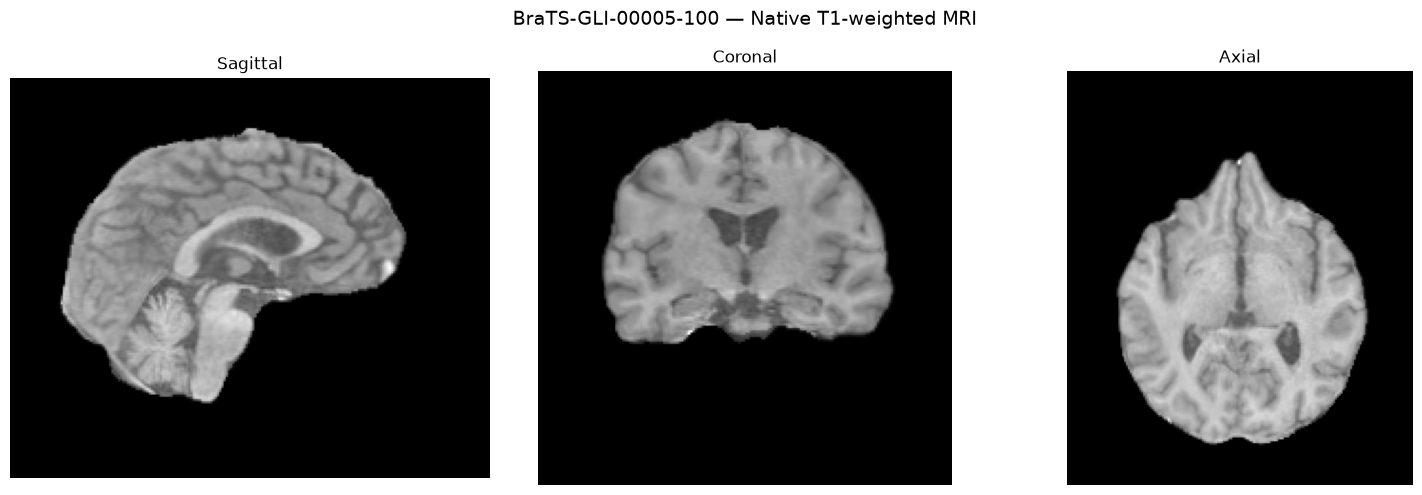

In [19]:
# -------------------------------------------------------------
# VISUALISE THE THREE ANATOMICAL PLANES
# -------------------------------------------------------------
#
# imshow() displays each extracted 2D NumPy array as an image.
#
# cmap="gray" displays MRI signal intensity using a grayscale
# colour map.
#
# origin="lower" controls how array coordinates are positioned
# on the plotting axes.
#
# We transpose each slice because NumPy array indexing and
# Matplotlib's display convention use their axes differently.
# This makes the displayed anatomy easier to interpret in the
# expected orientation.

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

axes[0].imshow(
    sagittal_slice.T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Sagittal")

axes[1].imshow(
    coronal_slice.T,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Coronal")

axes[2].imshow(
    axial_slice.T,
    cmap="gray",
    origin="lower"
)
axes[2].set_title("Axial")

for axis in axes:
    axis.axis("off")

plt.suptitle(
    f"{example_case_id} — Native T1-weighted MRI",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 10. Comparing the Four MRI Modalities

BraTS provides four complementary MRI sequences for each case:

- **T1 native (`t1n`)** — provides anatomical T1-weighted information;
- **T1 contrast-enhanced (`t1c`)** — demonstrates areas of contrast enhancement;
- **T2-weighted (`t2w`)** — emphasizes tissues with prolonged T2 signal;
- **T2-FLAIR (`t2f`)** — suppresses free-fluid signal and helps demonstrate
  abnormal T2/FLAIR hyperintensity within the brain.

These sequences provide complementary information about tumour morphology and
the surrounding brain.

In a multimodal segmentation model, the four MRI volumes can subsequently be
combined as separate input channels, allowing the network to learn spatial
relationships between findings across the different sequences.

In [20]:
# -------------------------------------------------------------
# LOAD ALL FOUR MRI MODALITIES
# -------------------------------------------------------------
#
# We already loaded the native T1-weighted image above.
#
# We now load the contrast-enhanced T1, T2-weighted and
# T2-FLAIR volumes for the same case.
#
# Each modality is converted to a NumPy array so that the
# voxel data can be inspected and visualised.

t1c_image = nib.load(t1c_path)
t2w_image = nib.load(t2w_path)
t2f_image = nib.load(t2f_path)

t1c_volume = t1c_image.get_fdata()
t2w_volume = t2w_image.get_fdata()
t2f_volume = t2f_image.get_fdata()

print("T1 native shape:   ", t1n_volume.shape)
print("T1 contrast shape: ", t1c_volume.shape)
print("T2 weighted shape: ", t2w_volume.shape)
print("T2-FLAIR shape:    ", t2f_volume.shape)

T1 native shape:    (182, 218, 182)
T1 contrast shape:  (182, 218, 182)
T2 weighted shape:  (182, 218, 182)
T2-FLAIR shape:     (182, 218, 182)


In [21]:
# -------------------------------------------------------------
# CHECK MULTIMODAL SPATIAL CONSISTENCY
# -------------------------------------------------------------
#
# Multimodal MRI volumes must correspond spatially if they are
# going to be combined voxel-for-voxel.
#
# Here we check:
#   1. whether all four arrays have the same shape;
#   2. whether their affine matrices are numerically equivalent.
#
# np.allclose() is used for the affine matrices because they
# contain floating-point values.

same_shape = (
    t1n_volume.shape
    == t1c_volume.shape
    == t2w_volume.shape
    == t2f_volume.shape
)

same_affine = (
    np.allclose(t1n_image.affine, t1c_image.affine)
    and np.allclose(t1n_image.affine, t2w_image.affine)
    and np.allclose(t1n_image.affine, t2f_image.affine)
)

print("All modalities have the same shape:", same_shape)
print("All modalities have the same affine:", same_affine)

All modalities have the same shape: True
All modalities have the same affine: True


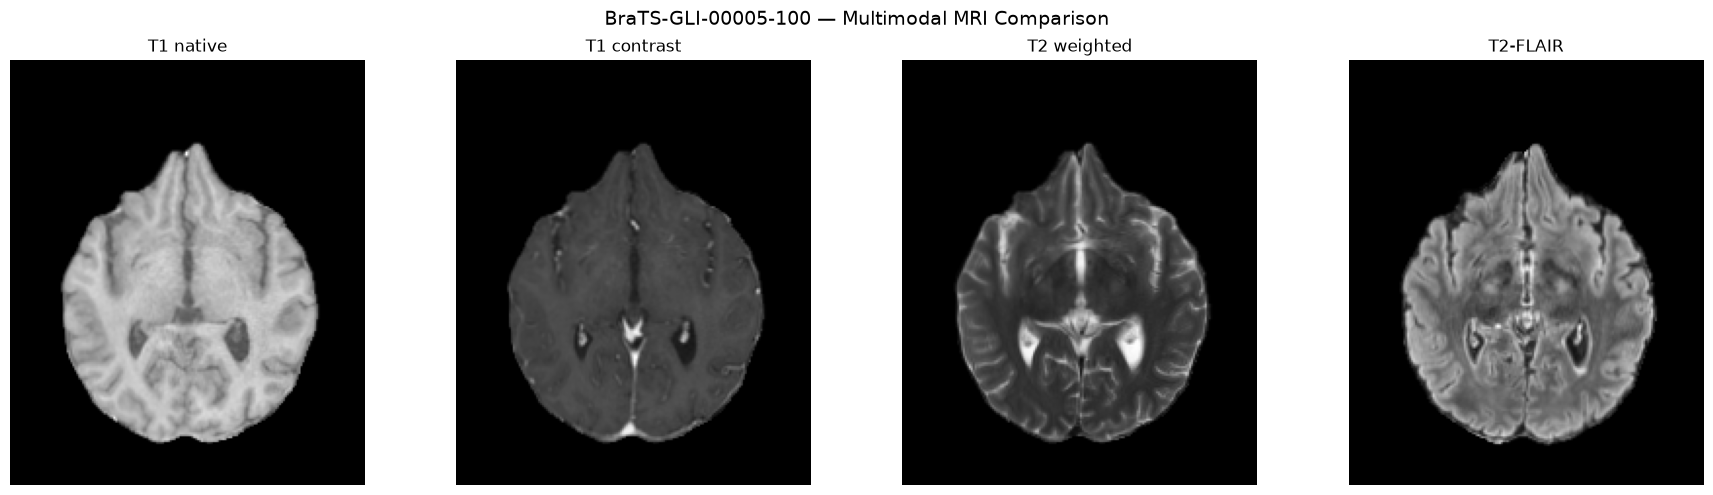

In [22]:
# -------------------------------------------------------------
# COMPARE MRI MODALITIES AT THE SAME AXIAL LOCATION
# -------------------------------------------------------------
#
# Using exactly the same slice index for all four modalities
# allows us to compare their signal characteristics at the
# same spatial location.
#
# We use the central axial slice initially. Later, after
# loading the segmentation mask, we will automatically select
# slices that actually contain tumour.

axial_slices = {
    "T1 native": t1n_volume[:, :, axial_index],
    "T1 contrast": t1c_volume[:, :, axial_index],
    "T2 weighted": t2w_volume[:, :, axial_index],
    "T2-FLAIR": t2f_volume[:, :, axial_index],
}

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

for axis, (title, image_slice) in zip(
    axes,
    axial_slices.items()
):
    axis.imshow(
        image_slice.T,
        cmap="gray",
        origin="lower"
    )
    axis.set_title(title)
    axis.axis("off")

plt.suptitle(
    f"{example_case_id} — Multimodal MRI Comparison",
    fontsize=14
)

plt.tight_layout()
plt.show()

## 11. Exploring the Reference Tumour Segmentation

The BraTS training dataset provides a reference segmentation for each case.

Unlike the MRI volumes, whose voxel values represent image signal intensity,
the segmentation volume is a **label map**. Each voxel contains a discrete
integer identifying whether that location belongs to background or a
particular tumour-related region.

The segmentation will first be inspected independently before being overlaid
on the corresponding MRI.

This also allows tumour-containing slices to be identified objectively rather
than selecting slices based only on the geometric centre of the MRI volume.

In [23]:
# -------------------------------------------------------------
# LOAD THE REFERENCE SEGMENTATION
# -------------------------------------------------------------
#
# The segmentation is stored as another NIfTI volume.
#
# Spatially, it should correspond to the MRI modalities, but
# its voxel values have a completely different meaning:
#
# MRI voxel values -> signal intensity
# Segmentation values -> discrete class labels

seg_image = nib.load(seg_path)
seg_volume = seg_image.get_fdata()

print("Segmentation shape:")
print(seg_volume.shape)

print("\nSegmentation voxel spacing:")
print(seg_image.header.get_zooms())

print("\nSegmentation orientation:")
print(nib.aff2axcodes(seg_image.affine))

print("\nSegmentation matches MRI shape:")
print(seg_volume.shape == t1n_volume.shape)

print("\nSegmentation matches MRI affine:")
print(np.allclose(seg_image.affine, t1n_image.affine))

Segmentation shape:
(182, 218, 182)

Segmentation voxel spacing:
(np.float32(1.0), np.float32(1.0), np.float32(1.0))

Segmentation orientation:
('L', 'A', 'S')

Segmentation matches MRI shape:
True

Segmentation matches MRI affine:
True


In [24]:
# -------------------------------------------------------------
# INSPECT SEGMENTATION LABEL VALUES
# -------------------------------------------------------------
#
# A segmentation mask contains discrete class labels rather
# than continuous MRI intensities.
#
# np.unique() identifies every distinct value occurring in the
# segmentation and how many voxels belong to each label.
#
# We inspect the actual dataset before assigning biological
# meanings to those labels.

segmentation_labels, label_counts = np.unique(
    seg_volume,
    return_counts=True
)

print("Unique segmentation labels:")
print(segmentation_labels)

print("\nVoxel counts by label:")

for label, count in zip(
    segmentation_labels,
    label_counts
):
    print(
        f"Label {int(label)}: {count:,} voxels"
    )

Unique segmentation labels:
[0. 2. 4.]

Voxel counts by label:
Label 0: 7,193,826 voxels
Label 2: 22,960 voxels
Label 4: 4,246 voxels


In [25]:
# -------------------------------------------------------------
# FIND THE AXIAL SLICE WITH THE LARGEST TUMOUR AREA
# -------------------------------------------------------------
#
# All non-zero segmentation labels represent tumour-related
# regions, so we first create a binary tumour mask.
#
# We then count the number of tumour voxels in every axial
# slice.
#
# The slice with the largest count provides a useful,
# reproducible location for visual exploration of this case.

tumour_mask = seg_volume > 0

tumour_voxels_per_axial_slice = tumour_mask.sum(
    axis=(0, 1)
)

max_tumour_axial_index = int(
    np.argmax(tumour_voxels_per_axial_slice)
)

max_tumour_voxel_count = int(
    tumour_voxels_per_axial_slice[
        max_tumour_axial_index
    ]
)

print(
    "Axial slice with largest segmented tumour area:",
    max_tumour_axial_index
)

print(
    "Tumour voxels in that slice:",
    max_tumour_voxel_count
)

Axial slice with largest segmented tumour area: 124
Tumour voxels in that slice: 1098


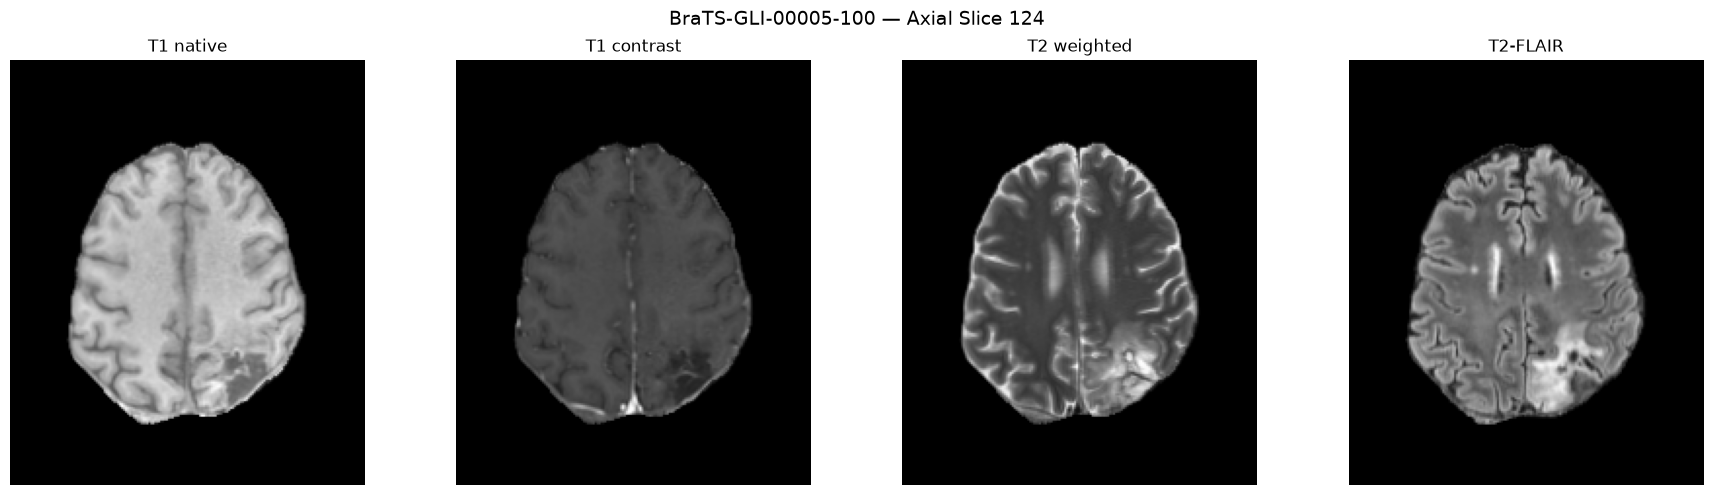

In [26]:
# -------------------------------------------------------------
# COMPARE ALL MRI MODALITIES AT THE MAXIMUM-TUMOUR SLICE
# -------------------------------------------------------------
#
# Previously we compared the modalities at the geometric
# centre of the brain.
#
# We now use the reference segmentation to select the axial
# slice containing the largest segmented tumour area. This
# provides a more informative comparison of how the tumour
# appears across the four MRI sequences.

tumour_axial_slices = {
    "T1 native": t1n_volume[
        :, :, max_tumour_axial_index
    ],
    "T1 contrast": t1c_volume[
        :, :, max_tumour_axial_index
    ],
    "T2 weighted": t2w_volume[
        :, :, max_tumour_axial_index
    ],
    "T2-FLAIR": t2f_volume[
        :, :, max_tumour_axial_index
    ],
}

fig, axes = plt.subplots(
    1,
    4,
    figsize=(18, 5)
)

for axis, (title, image_slice) in zip(
    axes,
    tumour_axial_slices.items()
):
    axis.imshow(
        image_slice.T,
        cmap="gray",
        origin="lower"
    )

    axis.set_title(title)
    axis.axis("off")

plt.suptitle(
    (
        f"{example_case_id} — "
        f"Axial Slice {max_tumour_axial_index}"
    ),
    fontsize=14
)

plt.tight_layout()
plt.show()

## 12. Visualising the Reference Segmentation

The BraTS reference segmentation occupies the same voxel grid and physical
coordinate system as the four MRI modalities.

Unlike MRI intensity data, the segmentation contains discrete integer labels
representing tumour-related tissue compartments.

For the BraTS glioma segmentation convention used here:

- `0` — background;
- `1` — necrotic/non-enhancing tumour core;
- `2` — peritumoral edematous/invaded tissue;
- `4` — enhancing tumour.

Not every tumour contains voxels belonging to every label. In the representative
case examined here, labels 2 and 4 are present, while label 1 is absent.

For some analyses, all non-zero labels can also be combined into a binary mask
representing the complete labelled lesion.

In [27]:
# -------------------------------------------------------------
# EXTRACT THE SEGMENTATION AT THE MAXIMUM-TUMOUR SLICE
# -------------------------------------------------------------
#
# We use the same axial index that was identified from the
# 3D segmentation as containing the largest number of
# tumour-labelled voxels.
#
# Two versions are extracted:
#
#   segmentation_slice -> retains the original class labels
#   binary_tumour_slice -> combines all non-zero labels
#
# The binary version is useful for showing the overall spatial
# extent of the labelled lesion without yet assigning biological
# interpretations to individual BraTS labels.

segmentation_slice = seg_volume[
    :, :, max_tumour_axial_index
]

binary_tumour_slice = (
    segmentation_slice > 0
)

print(
    "Segmentation labels on this slice:",
    np.unique(segmentation_slice)
)

print(
    "Tumour voxels on this slice:",
    int(binary_tumour_slice.sum())
)

Segmentation labels on this slice: [0. 2. 4.]
Tumour voxels on this slice: 1098


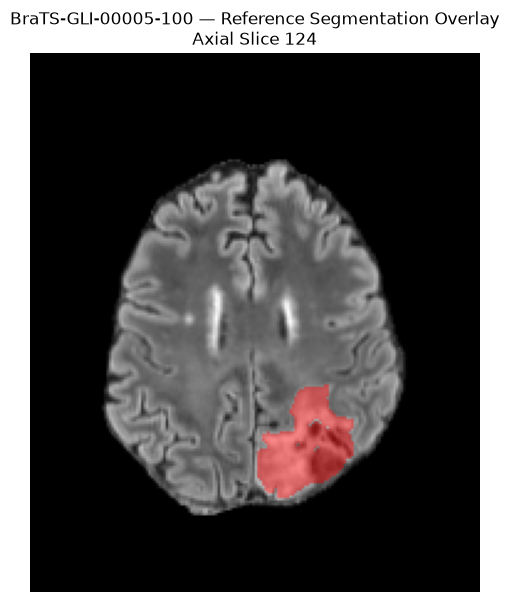

In [28]:
# -------------------------------------------------------------
# OVERLAY THE BINARY SEGMENTATION ON T2-FLAIR
# -------------------------------------------------------------
#
# First display the underlying FLAIR MRI in grayscale.
#
# We then place the binary reference segmentation on top with
# partial transparency (alpha), allowing both the MRI anatomy
# and labelled lesion location to remain visible.
#
# The masked array prevents background voxels from being
# coloured by the overlay.

flair_slice = t2f_volume[
    :, :, max_tumour_axial_index
]

masked_tumour = np.ma.masked_where(
    binary_tumour_slice == 0,
    binary_tumour_slice
)

plt.figure(
    figsize=(7, 7)
)

plt.imshow(
    flair_slice.T,
    cmap="gray",
    origin="lower"
)

plt.imshow(
    masked_tumour.T,
    cmap="autumn",
    alpha=0.45,
    origin="lower"
)

plt.title(
    (
        f"{example_case_id} — "
        f"Reference Segmentation Overlay\n"
        f"Axial Slice {max_tumour_axial_index}"
    )
)

plt.axis("off")
plt.show()

In [29]:
# -------------------------------------------------------------
# CALCULATE SEGMENTATION COMPARTMENT VOLUMES
# -------------------------------------------------------------
#
# The MRI has isotropic 1 × 1 × 1 mm voxels.
# Therefore, each voxel represents exactly 1 mm³.
#
# We calculate the volume occupied by each tumour-related
# segmentation label and convert from mm³ to cm³.
#
# Note that label 1 is absent in this particular case.

voxel_volume_mm3 = np.prod(
    seg_image.header.get_zooms()[:3]
)

tumour_labels = {
    1: "Necrotic/non-enhancing tumour core",
    2: "Peritumoral edematous/invaded tissue",
    4: "Enhancing tumour",
}

total_tumour_volume_mm3 = 0

for label, label_name in tumour_labels.items():

    voxel_count = np.sum(
        seg_volume == label
    )

    volume_mm3 = (
        voxel_count * voxel_volume_mm3
    )

    volume_cm3 = volume_mm3 / 1000

    total_tumour_volume_mm3 += volume_mm3

    print(
        f"{label_name}: "
        f"{voxel_count:,} voxels "
        f"({volume_cm3:.3f} cm³)"
    )

print(
    "\nCombined labelled volume:",
    f"{total_tumour_volume_mm3 / 1000:.3f} cm³"
)

Necrotic/non-enhancing tumour core: 0 voxels (0.000 cm³)
Peritumoral edematous/invaded tissue: 22,960 voxels (22.960 cm³)
Enhancing tumour: 4,246 voxels (4.246 cm³)

Combined labelled volume: 27.206 cm³


## 13. Quantifying Segmentation Volumes

Because the reference segmentation is a three-dimensional label map, the number
of voxels assigned to each tumour compartment can be converted into a physical
volume.

The physical volume represented by one voxel is determined from the NIfTI voxel
spacing:

\[
V_{\mathrm{voxel}} = \Delta x \times \Delta y \times \Delta z
\]

For this case, the voxel dimensions are 1 × 1 × 1 mm, so each voxel represents
1 mm³.

This allows the volumes of the individual labelled tumour compartments, and the
combined labelled lesion, to be calculated directly from the segmentation.

In [30]:
# -------------------------------------------------------------
# CALCULATE SEGMENTATION COMPARTMENT VOLUMES
# -------------------------------------------------------------
#
# Calculate the physical volume represented by one voxel from
# the NIfTI metadata rather than assuming that all datasets
# necessarily use 1 × 1 × 1 mm voxels.
#
# We then count the voxels belonging to each BraTS tumour label
# and convert their volumes from mm³ to cm³.
#
# Label 1 is included even though it is absent in this
# particular case. This makes the calculation applicable to
# cases containing all tumour compartments.

voxel_spacing = seg_image.header.get_zooms()[:3]

voxel_volume_mm3 = np.prod(
    voxel_spacing
)

tumour_labels = {
    1: "Necrotic/non-enhancing tumour core",
    2: "Peritumoral edematous/invaded tissue",
    4: "Enhancing tumour",
}

total_tumour_volume_mm3 = 0

print(
    f"Voxel volume: {voxel_volume_mm3:.3f} mm³\n"
)

for label, label_name in tumour_labels.items():

    voxel_count = int(
        np.sum(seg_volume == label)
    )

    volume_mm3 = (
        voxel_count * voxel_volume_mm3
    )

    volume_cm3 = (
        volume_mm3 / 1000
    )

    total_tumour_volume_mm3 += volume_mm3

    print(
        f"{label_name}: "
        f"{voxel_count:,} voxels "
        f"({volume_cm3:.3f} cm³)"
    )

print(
    "\nCombined labelled volume:",
    f"{total_tumour_volume_mm3 / 1000:.3f} cm³"
)

Voxel volume: 1.000 mm³

Necrotic/non-enhancing tumour core: 0 voxels (0.000 cm³)
Peritumoral edematous/invaded tissue: 22,960 voxels (22.960 cm³)
Enhancing tumour: 4,246 voxels (4.246 cm³)

Combined labelled volume: 27.206 cm³


## 14. Visualising Individual Tumour Compartments

The previous overlay combined all non-zero segmentation labels into a single
binary lesion mask.

The reference segmentation can also be separated into its individual labelled
components. This allows the spatial relationship between different tumour
regions and the underlying MRI appearance to be examined.

For this representative case:

- label `1` (necrotic/non-enhancing tumour core) is absent;
- label `2` represents peritumoral edematous/invaded tissue;
- label `4` represents enhancing tumour.

The individual masks are visualised on the same axial slice used previously,
which contains the largest cross-sectional area of the complete labelled lesion.

In [31]:
# -------------------------------------------------------------
# CREATE LABEL-SPECIFIC SEGMENTATION MASKS
# -------------------------------------------------------------
#
# Instead of treating every non-zero segmentation voxel as
# belonging to one class, we create a separate Boolean mask
# for each tumour-related label.
#
# A voxel is True only when it belongs to that particular
# segmentation class.

label_1_mask = (
    segmentation_slice == 1
)

label_2_mask = (
    segmentation_slice == 2
)

label_4_mask = (
    segmentation_slice == 4
)

print(
    "Label 1 voxels on this slice:",
    int(label_1_mask.sum())
)

print(
    "Label 2 voxels on this slice:",
    int(label_2_mask.sum())
)

print(
    "Label 4 voxels on this slice:",
    int(label_4_mask.sum())
)

print(
    "\nTotal labelled voxels:",
    int(
        label_1_mask.sum()
        + label_2_mask.sum()
        + label_4_mask.sum()
    )
)

Label 1 voxels on this slice: 0
Label 2 voxels on this slice: 781
Label 4 voxels on this slice: 317

Total labelled voxels: 1098


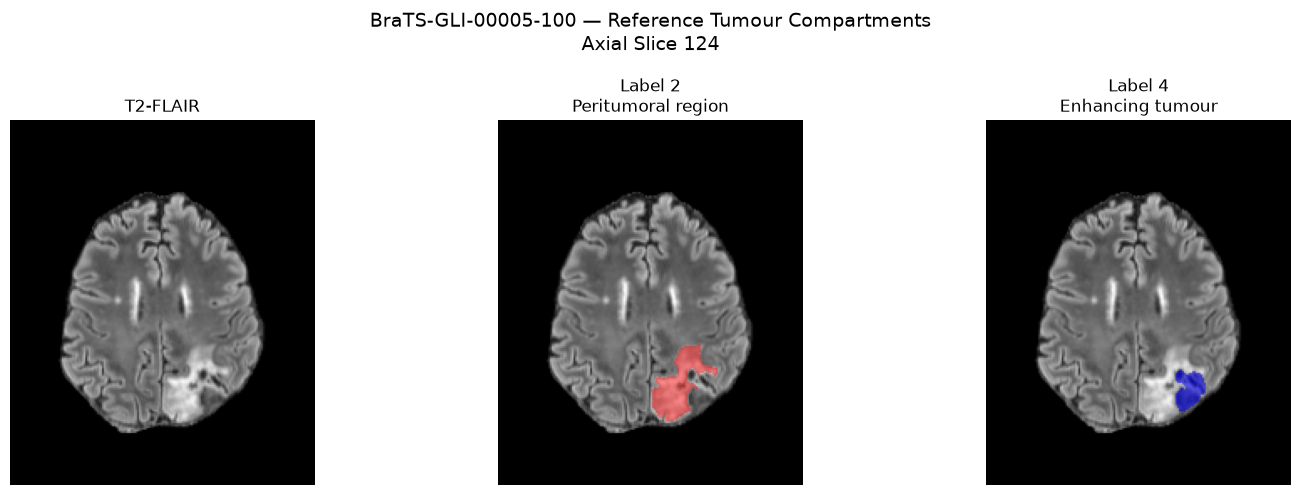

In [32]:
# -------------------------------------------------------------
# VISUALISE INDIVIDUAL SEGMENTATION LABELS
# -------------------------------------------------------------
#
# Display the same T2-FLAIR slice three times:
#
#   1. MRI without an overlay;
#   2. MRI with label 2 overlaid;
#   3. MRI with label 4 overlaid.
#
# This makes the spatial contribution of each segmentation
# compartment easier to understand before combining them into
# a multi-class visualization.

label_2_overlay = np.ma.masked_where(
    label_2_mask == 0,
    label_2_mask
)

label_4_overlay = np.ma.masked_where(
    label_4_mask == 0,
    label_4_mask
)

fig, axes = plt.subplots(
    1,
    3,
    figsize=(15, 5)
)

# Original T2-FLAIR MRI.
axes[0].imshow(
    flair_slice.T,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("T2-FLAIR")

# Label 2 overlay.
axes[1].imshow(
    flair_slice.T,
    cmap="gray",
    origin="lower"
)
axes[1].imshow(
    label_2_overlay.T,
    cmap="autumn",
    alpha=0.45,
    origin="lower"
)
axes[1].set_title(
    "Label 2\nPeritumoral region"
)

# Label 4 overlay.
axes[2].imshow(
    flair_slice.T,
    cmap="gray",
    origin="lower"
)
axes[2].imshow(
    label_4_overlay.T,
    cmap="winter",
    alpha=0.55,
    origin="lower"
)
axes[2].set_title(
    "Label 4\nEnhancing tumour"
)

for axis in axes:
    axis.axis("off")

plt.suptitle(
    (
        f"{example_case_id} — "
        f"Reference Tumour Compartments\n"
        f"Axial Slice {max_tumour_axial_index}"
    ),
    fontsize=14
)

plt.tight_layout()
plt.show()

## MRI Intensity Analysis and Preprocessing

MRI voxel intensities do not have a universal standardized scale comparable
to Hounsfield units in CT. Intensity distributions may vary between MRI
sequences, scanners, acquisition protocols and patients.

Before using the MRI volumes as inputs to a deep-learning model, the intensity
distributions should therefore be examined and an appropriate normalization
strategy selected.

Because voxels outside the brain are represented predominantly by zero-valued
background, intensity statistics will initially be calculated using only
non-zero voxels.

In [33]:
# -------------------------------------------------------------
# EXAMINE MRI INTENSITY DISTRIBUTIONS
# -------------------------------------------------------------
#
# MRI intensities are not measured on a universal scale.
# Before normalizing the images for deep learning, we first
# examine the distribution of voxel intensities in each MRI
# sequence.
#
# Zero-valued voxels are excluded because they predominantly
# represent background outside the imaged brain. Including them
# would distort the statistics of the actual MRI signal.

modalities = {
    "T1n": t1n_volume,
    "T1c": t1c_volume,
    "T2w": t2w_volume,
    "T2-FLAIR": t2f_volume,
}

for modality_name, volume in modalities.items():

    # Select only voxels containing non-zero image signal.
    foreground_voxels = volume[volume > 0]

    print(f"{modality_name}")
    print(f"  Foreground voxels: {foreground_voxels.size:,}")
    print(f"  Mean:              {foreground_voxels.mean():.2f}")
    print(f"  Standard deviation:{foreground_voxels.std():.2f}")
    print(f"  Median:            {np.median(foreground_voxels):.2f}")
    print(f"  Minimum:           {foreground_voxels.min():.2f}")
    print(f"  Maximum:           {foreground_voxels.max():.2f}")
    print()

T1n
  Foreground voxels: 1,239,035
  Mean:              1710.39
  Standard deviation:424.24
  Median:            1816.48
  Minimum:           0.00
  Maximum:           4300.92

T1c
  Foreground voxels: 1,239,035
  Mean:              2081.59
  Standard deviation:615.88
  Median:            2127.37
  Minimum:           0.00
  Maximum:           8183.82

T2w
  Foreground voxels: 1,239,035
  Mean:              709.04
  Standard deviation:368.93
  Median:            610.44
  Minimum:           0.00
  Maximum:           2519.35

T2-FLAIR
  Foreground voxels: 1,239,009
  Mean:              466.77
  Standard deviation:169.49
  Median:            475.86
  Minimum:           0.00
  Maximum:           1406.90



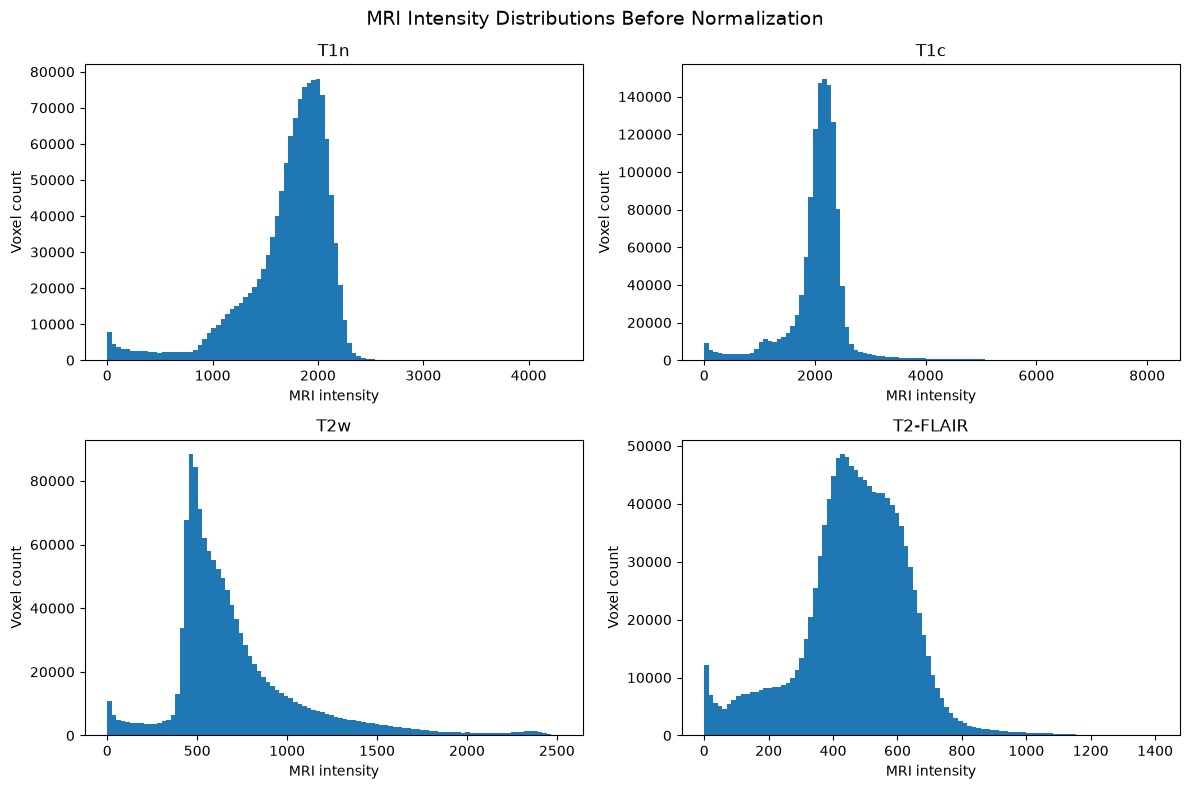

In [34]:
# -------------------------------------------------------------
# VISUALIZE MRI INTENSITY DISTRIBUTIONS
# -------------------------------------------------------------
#
# Histograms allow us to compare the numerical intensity
# distributions of the four MRI modalities.
#
# Only positive-valued voxels are included so that the large
# zero-valued background outside the brain does not dominate
# the histograms.

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for axis, (modality_name, volume) in zip(
    axes,
    modalities.items()
):

    # Extract non-zero image voxels.
    foreground_voxels = volume[volume > 0]

    axis.hist(
        foreground_voxels,
        bins=100
    )

    axis.set_title(modality_name)
    axis.set_xlabel("MRI intensity")
    axis.set_ylabel("Voxel count")

plt.suptitle(
    "MRI Intensity Distributions Before Normalization",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Modality-wise intensity normalization

The four MRI modalities have substantially different raw intensity
distributions. Because MRI signal intensity does not have a universal
quantitative scale, these numerical differences should not be interpreted
as differences in biological importance between modalities.

Each MRI modality is therefore normalized independently using z-score
normalization. The mean and standard deviation are calculated from
non-zero voxels only, while zero-valued background voxels are preserved.

After normalization, the foreground voxels of each modality should have
approximately zero mean and unit standard deviation.

In [35]:
# -------------------------------------------------------------
# Z-SCORE NORMALIZE EACH MRI MODALITY
# -------------------------------------------------------------
#
# Each MRI sequence is normalized independently.
#
# For the non-zero foreground voxels:
#
#     normalized intensity = (intensity - mean) / standard deviation
#
# The zero-valued background is deliberately left at zero rather
# than being included in the calculation or transformed.

def zscore_normalize_foreground(volume):
    """
    Z-score normalize the non-zero voxels of a 3D MRI volume.

    Parameters
    ----------
    volume : np.ndarray
        Three-dimensional MRI volume.

    Returns
    -------
    normalized_volume : np.ndarray
        Volume with normalized foreground intensities while
        preserving zero-valued background.
    """

    # Identify voxels containing MRI signal.
    foreground_mask = volume > 0

    # Extract foreground values for calculating normalization
    # statistics.
    foreground_voxels = volume[foreground_mask]

    foreground_mean = foreground_voxels.mean()
    foreground_std = foreground_voxels.std()

    # Start with an array of zeros so that background voxels
    # remain zero after normalization.
    normalized_volume = np.zeros_like(
        volume,
        dtype=np.float32
    )

    # Normalize only the foreground.
    normalized_volume[foreground_mask] = (
        volume[foreground_mask] - foreground_mean
    ) / foreground_std

    return normalized_volume


normalized_modalities = {
    modality_name: zscore_normalize_foreground(volume)
    for modality_name, volume in modalities.items()
}

In [36]:
# -------------------------------------------------------------
# VERIFY NORMALIZATION
# -------------------------------------------------------------
#
# If z-score normalization has worked correctly, the non-zero
# foreground used for normalization should have approximately:
#
#     mean = 0
#     standard deviation = 1
#
# We use the ORIGINAL foreground mask here. This is important
# because normalized foreground voxels can legitimately become
# zero or negative.

for modality_name, original_volume in modalities.items():

    normalized_volume = normalized_modalities[modality_name]

    # Recover the foreground mask from the original MRI volume.
    foreground_mask = original_volume > 0

    normalized_foreground = normalized_volume[foreground_mask]

    print(f"{modality_name}")
    print(
        f"  Mean after normalization: "
        f"{normalized_foreground.mean():.6f}"
    )
    print(
        f"  SD after normalization:   "
        f"{normalized_foreground.std():.6f}"
    )
    print()

T1n
  Mean after normalization: 0.000000
  SD after normalization:   1.000000

T1c
  Mean after normalization: -0.000000
  SD after normalization:   1.000000

T2w
  Mean after normalization: -0.000000
  SD after normalization:   1.000000

T2-FLAIR
  Mean after normalization: 0.000000
  SD after normalization:   1.000000



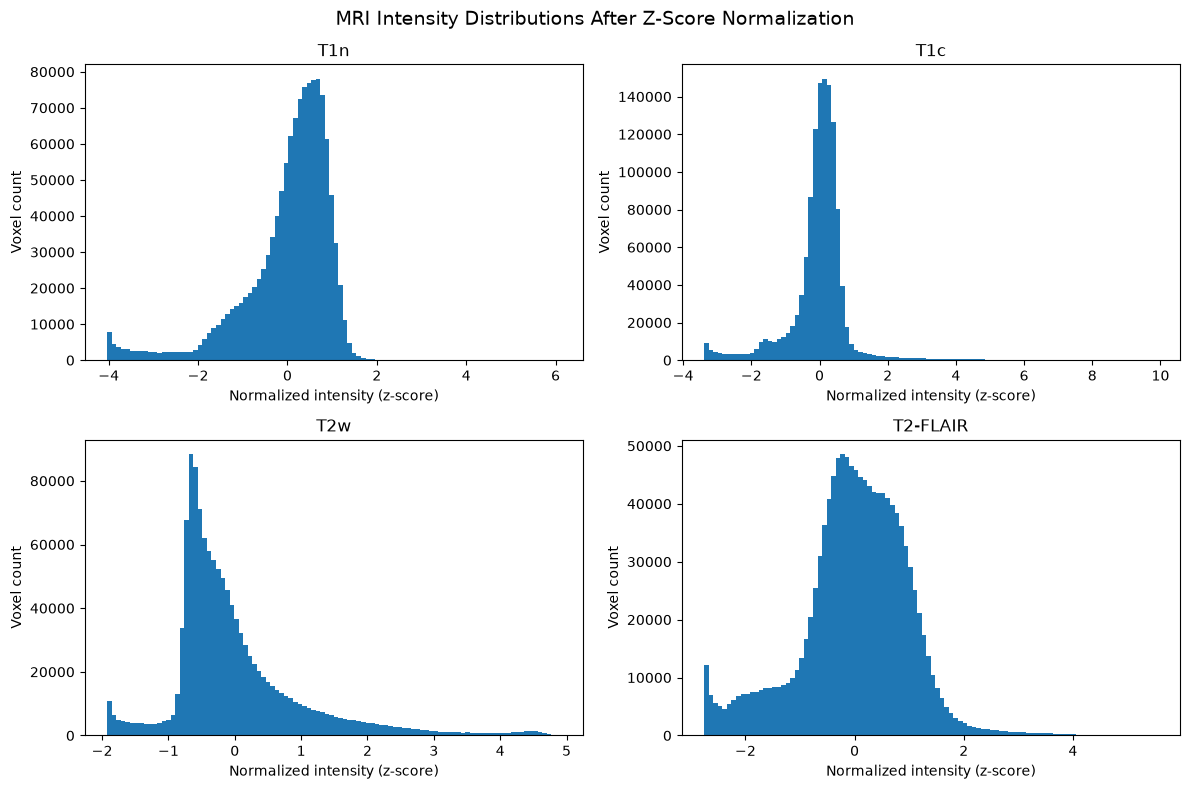

In [37]:
# -------------------------------------------------------------
# VISUALIZE NORMALIZED MRI INTENSITY DISTRIBUTIONS
# -------------------------------------------------------------
#
# After modality-wise z-score normalization, the foreground
# intensity distributions should all be centred approximately
# around zero and expressed in units of standard deviation.
#
# Importantly, normalization does not force the distributions
# to have the same shape. Each MRI sequence still contains
# different tissue contrast and biological information.

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 8)
)

axes = axes.flatten()

for axis, (modality_name, original_volume) in zip(
    axes,
    modalities.items()
):

    normalized_volume = normalized_modalities[modality_name]

    # Use the original MRI to identify foreground voxels.
    foreground_mask = original_volume > 0

    normalized_foreground = normalized_volume[foreground_mask]

    axis.hist(
        normalized_foreground,
        bins=100
    )

    axis.set_title(modality_name)
    axis.set_xlabel("Normalized intensity (z-score)")
    axis.set_ylabel("Voxel count")

plt.suptitle(
    "MRI Intensity Distributions After Z-Score Normalization",
    fontsize=14
)

plt.tight_layout()
plt.show()

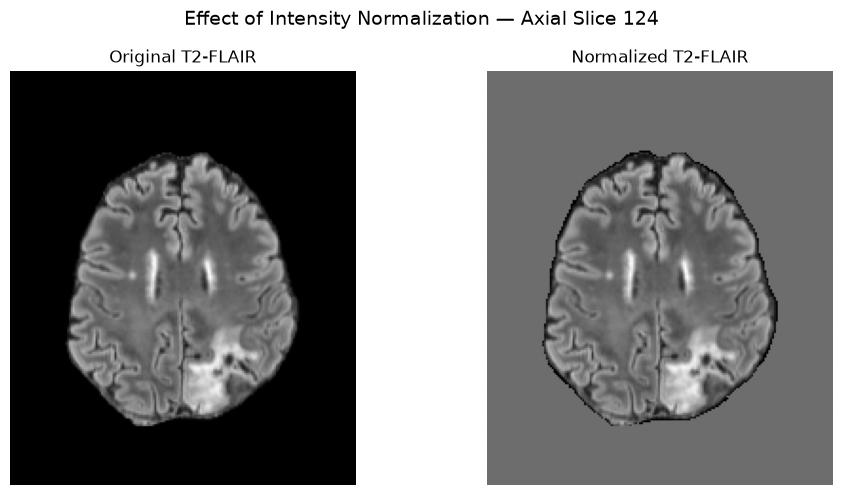

In [38]:
# -------------------------------------------------------------
# COMPARE MRI BEFORE AND AFTER NORMALIZATION
# -------------------------------------------------------------
#
# Z-score normalization changes the numerical intensity scale,
# but it should preserve the underlying anatomy and spatial
# structure of the MRI.
#
# We compare the original and normalized T2-FLAIR image using
# the same tumour-containing axial slice identified earlier.

original_flair_slice = t2f_volume[:, :, max_tumour_axial_index].T

normalized_flair_slice = (
    normalized_modalities["T2-FLAIR"][
        :, :, max_tumour_axial_index
    ].T
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 5)
)

axes[0].imshow(
    original_flair_slice,
    cmap="gray",
    origin="lower"
)
axes[0].set_title("Original T2-FLAIR")
axes[0].axis("off")

axes[1].imshow(
    normalized_flair_slice,
    cmap="gray",
    origin="lower"
)
axes[1].set_title("Normalized T2-FLAIR")
axes[1].axis("off")

plt.suptitle(
    f"Effect of Intensity Normalization — Axial Slice "
    f"{max_tumour_axial_index}",
    fontsize=14
)

plt.tight_layout()
plt.show()

## Constructing Multimodal Model Input

A 3D segmentation network receives the four MRI modalities as separate
input channels. Because the BraTS modalities are spatially aligned, the
corresponding voxel coordinates across T1n, T1c, T2w and T2-FLAIR represent
the same anatomical location.

The independently normalized MRI volumes can therefore be stacked along a
new channel dimension.

For one patient, the resulting input has the structure:

`[channels, x, y, z]`

where the four channels correspond to T1n, T1c, T2w and T2-FLAIR.

In [39]:
# -------------------------------------------------------------
# STACK THE FOUR MRI MODALITIES INTO ONE MODEL INPUT
# -------------------------------------------------------------
#
# A 3D neural network expects the different MRI sequences to be
# represented as separate channels of the same input volume.
#
# The channel order used here is:
#
#     0 = T1n
#     1 = T1c
#     2 = T2w
#     3 = T2-FLAIR
#
# Each channel has already been normalized independently.

multimodal_input = np.stack(
    [
        normalized_modalities["T1n"],
        normalized_modalities["T1c"],
        normalized_modalities["T2w"],
        normalized_modalities["T2-FLAIR"],
    ],
    axis=0
)

print("Multimodal input shape:", multimodal_input.shape)
print("Data type:", multimodal_input.dtype)

Multimodal input shape: (4, 182, 218, 182)
Data type: float32


## Preparing the Segmentation Target

The BraTS reference segmentation provides the ground-truth class assigned
to each voxel.

The original labels are `0`, `1`, `2` and `4`. For a conventional
multiclass segmentation target, these labels are remapped to contiguous
class indices `0`, `1`, `2` and `3`.

This remapping changes only the numerical representation of the enhancing
tumour label; it does not alter the spatial segmentation.

In [40]:
# -------------------------------------------------------------
# PREPARE A CONTIGUOUS MULTICLASS SEGMENTATION TARGET
# -------------------------------------------------------------
#
# Original BraTS labels:
#
#     0 = background
#     1 = necrotic / non-enhancing tumour core
#     2 = peritumoral region
#     4 = enhancing tumour
#
# For a conventional four-class segmentation model, label 4 is
# remapped to class index 3 so that the target classes are
# contiguous: 0, 1, 2, 3.

segmentation_target = seg_volume.astype(np.int64).copy()

segmentation_target[segmentation_target == 4] = 3

print(
    "Original segmentation labels:",
    np.unique(seg_volume)
)

print(
    "Model target labels:",
    np.unique(segmentation_target)
)

print(
    "Segmentation target shape:",
    segmentation_target.shape
)

print(
    "Segmentation target dtype:",
    segmentation_target.dtype
)

Original segmentation labels: [0. 2. 4.]
Model target labels: [0 2 3]
Segmentation target shape: (182, 218, 182)
Segmentation target dtype: int64
